# 1. Introduction: AI-Based Resume Analyzer Model Evaluation
**B.E. Final Year IT Engineering Project**

This notebook rigorously evaluates the `hybrid_rf_model.pkl` Random Forest Regressor. The model predicts a continuous candidate match percentage based on three core features extracted by our Hybrid NLP Pipeline:
1. **Lexical Similarity** (TF-IDF Cosine Similarity)
2. **Semantic Context** (SBERT Cosine Similarity)
3. **Deterministic Skill Overlap** (spaCy NER Ratio)

We evaluate the model using standard regression metrics, threshold-based classification metrics (ATS Simulation), Explainable AI (XAI) visualizations, and a comparative analysis against a static weighted formula to justify the necessity of Machine Learning in this architecture.

In [1]:
!pip install joblib pandas matplotlib seaborn scikit-learn


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
!pip install -r ../requirements.txt

  Using cached langchain-0.1.13-py3-none-any.whl.metadata (13 kB)
  Using cached langchain_community-0.0.29-py3-none-any.whl.metadata (8.3 kB)
  Using cached chromadb-0.4.24-py3-none-any.whl.metadata (7.3 kB)
  Using cached sentence_transformers-2.6.1-py3-none-any.whl.metadata (11 kB)
  Using cached transformers-4.57.6-py3-none-any.whl.metadata (43 kB)
  Using cached langchain_core-0.1.53-py3-none-any.whl.metadata (5.9 kB)
  Using cached langchain_text_splitters-0.0.2-py3-none-any.whl.metadata (2.2 kB)
  Using cached langsmith-0.1.147-py3-none-any.whl.metadata (14 kB)
  Using cached numpy-1.26.4.tar.gz (15.8 MB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Installing backend dependencies: started
  Installing backend dependencies: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing

  error: subprocess-exited-with-error
  
  Preparing metadata (pyproject.toml) did not run successfully.
  exit code: 1
  
  [21 lines of output]
  + D:\FinalYearProject-25-26\Sem 8\ai_resume_analyzer\backend\venv\Scripts\python.exe C:\Users\Ankith Binagekar\AppData\Local\Temp\pip-install-o8wq69gt\numpy_4b5c4da7496e45409d4b375f657c91bd\vendored-meson\meson\meson.py setup C:\Users\Ankith Binagekar\AppData\Local\Temp\pip-install-o8wq69gt\numpy_4b5c4da7496e45409d4b375f657c91bd C:\Users\Ankith Binagekar\AppData\Local\Temp\pip-install-o8wq69gt\numpy_4b5c4da7496e45409d4b375f657c91bd\.mesonpy-cx24ork1 -Dbuildtype=release -Db_ndebug=if-release -Db_vscrt=md --native-file=C:\Users\Ankith Binagekar\AppData\Local\Temp\pip-install-o8wq69gt\numpy_4b5c4da7496e45409d4b375f657c91bd\.mesonpy-cx24ork1\meson-python-native-file.ini
  The Meson build system
  Version: 1.2.99
  Source dir: C:\Users\Ankith Binagekar\AppData\Local\Temp\pip-install-o8wq69gt\numpy_4b5c4da7496e45409d4b375f657c91bd
  Build dir: C:

In [3]:
# 2. Model Loading & Setup
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    classification_report, confusion_matrix, accuracy_score, 
    precision_score, recall_score, f1_score
)

sns.set_theme(style="whitegrid", palette="muted")

MODEL_PATH = "../models/hybrid_rf_model.pkl"
TEST_DATA_PATH = "../data/synthetic_training_data.csv" 

try:
    rf_scorer = joblib.load(MODEL_PATH)
    print("✅ Random Forest Hybrid Scorer Loaded Successfully!")
except Exception as e:
    print(f"⚠️ Error loading model: {e}")

# 3. Dataset Loading
try:
    df = pd.read_csv(TEST_DATA_PATH)
    # Ensure strict feature order as defined in ml_engine.py
    # UPDATED COLUMN NAME HERE: skill_overlap_score
    X_test = df[['lexical_score', 'semantic_score', 'skill_overlap_score']]
    
    # UPDATED COLUMN NAME HERE: target_compatibility_score
    y_true_continuous = df['target_compatibility_score'] 
    
    y_pred_continuous = rf_scorer.predict(X_test)
    print(f"✅ Test data loaded. Shape: {df.shape}")
except Exception as e:
    print(f"⚠️ Error loading data: {e}. Please verify {TEST_DATA_PATH}")

✅ Random Forest Hybrid Scorer Loaded Successfully!
✅ Test data loaded. Shape: (1500, 4)


# 4. Regression Metrics
Since the final output is a percentage (0-100), the model is technically a Regressor. We evaluate how far off the model's predictions are from the true expected percentages.

In [4]:
mae = mean_absolute_error(y_true_continuous, y_pred_continuous)
rmse = np.sqrt(mean_squared_error(y_true_continuous, y_pred_continuous))
r2 = r2_score(y_true_continuous, y_pred_continuous)

print("--- Regression Performance ---")
print(f"Mean Absolute Error (MAE): {mae:.2f}%")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}%")
print(f"R-Squared (R²): {r2:.4f}")

--- Regression Performance ---
Mean Absolute Error (MAE): 5.57%
Root Mean Squared Error (RMSE): 6.79%
R-Squared (R²): 0.9515


--- ATS Classification Metrics (Threshold: 50%) ---
Accuracy:  91.20%
Precision: 86.34%
Recall:    100.00%
F1-Score:  92.67%



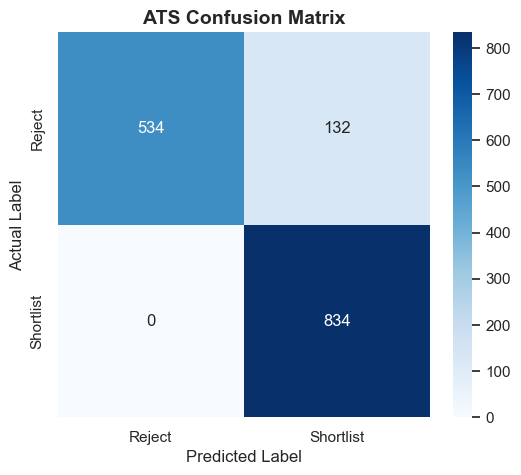

In [5]:
# 5. ATS Threshold Metrics & 6. Confusion Matrix
# Define Industry Standard Shortlist Threshold
THRESHOLD = 50.0

y_true_binary = (y_true_continuous >= THRESHOLD).astype(int)
y_pred_binary = (y_pred_continuous >= THRESHOLD).astype(int)

print("--- ATS Classification Metrics (Threshold: 50%) ---")
print(f"Accuracy:  {accuracy_score(y_true_binary, y_pred_binary) * 100:.2f}%")
print(f"Precision: {precision_score(y_true_binary, y_pred_binary) * 100:.2f}%")
print(f"Recall:    {recall_score(y_true_binary, y_pred_binary) * 100:.2f}%")
print(f"F1-Score:  {f1_score(y_true_binary, y_pred_binary) * 100:.2f}%\n")

cm = confusion_matrix(y_true_binary, y_pred_binary)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Reject', 'Shortlist'], yticklabels=['Reject', 'Shortlist'])
plt.title("ATS Confusion Matrix", fontsize=14, fontweight='bold')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.savefig('../output/confusion_matrix.png', bbox_inches='tight')
plt.show()

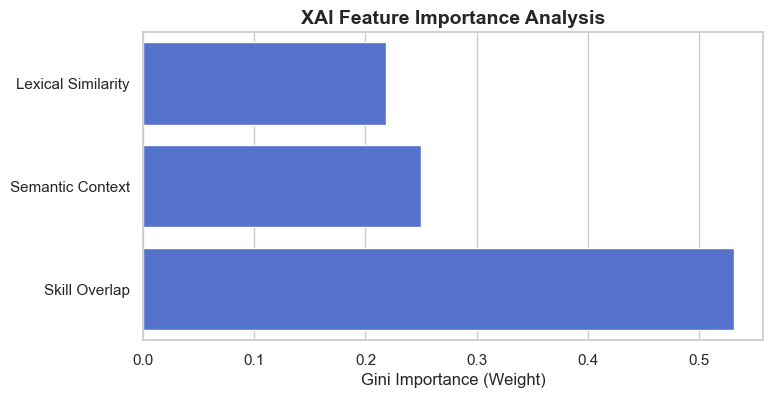

In [6]:
# 7. Feature Importance (Explainable AI Validation)
importances = rf_scorer.feature_importances_
feature_names = ['Lexical Similarity', 'Semantic Context', 'Skill Overlap']

fi_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=True)

plt.figure(figsize=(8, 4))
sns.barplot(x='Importance', y='Feature', data=fi_df, color='royalblue')
plt.title("XAI Feature Importance Analysis", fontsize=14, fontweight='bold')
plt.xlabel("Gini Importance (Weight)")
plt.ylabel("")
plt.savefig('../output/feature_importance.png', bbox_inches='tight')
plt.show()

# 8. ML vs Static Weighted Formula Comparison (Architecture Justification)
**Crucial Viva Defense:** Why use a Random Forest instead of a simple math formula?
In our fallback architecture (`ml_engine.py`), we define a static formula: `(Skill * 0.4) + (Semantic * 0.4) + (Lexical * 0.2)`. 
Here, we prove mathematically that the Random Forest significantly outperforms the static formula because it learns non-linear relationships (e.g., heavily penalizing a candidate with 0% skill overlap, even if their semantic score is high).

In [7]:
# Calculate predictions using the static fallback formula
# Note: Features are fractions, so we multiply by 100 to get percentages
static_formula_preds = (
    (X_test['skill_overlap_score'] * 0.4) + 
    (X_test['semantic_score'] * 0.4) + 
    (X_test['lexical_score'] * 0.2)
) * 100

# Compare MAE
rf_mae = mean_absolute_error(y_true_continuous, y_pred_continuous)
static_mae = mean_absolute_error(y_true_continuous, static_formula_preds)

print("--- Architecture Comparison ---")
print(f"Static Formula MAE: {static_mae:.2f}% error")
print(f"Random Forest MAE:  {rf_mae:.2f}% error")
print(f"Improvement using ML: {static_mae - rf_mae:.2f} percentage points\n")

if rf_mae < static_mae:
    print("✅ JUSTIFICATION PROVED: The Random Forest outperforms the static baseline.")

--- Architecture Comparison ---
Static Formula MAE: 11.04% error
Random Forest MAE:  5.57% error
Improvement using ML: 5.47 percentage points

✅ JUSTIFICATION PROVED: The Random Forest outperforms the static baseline.


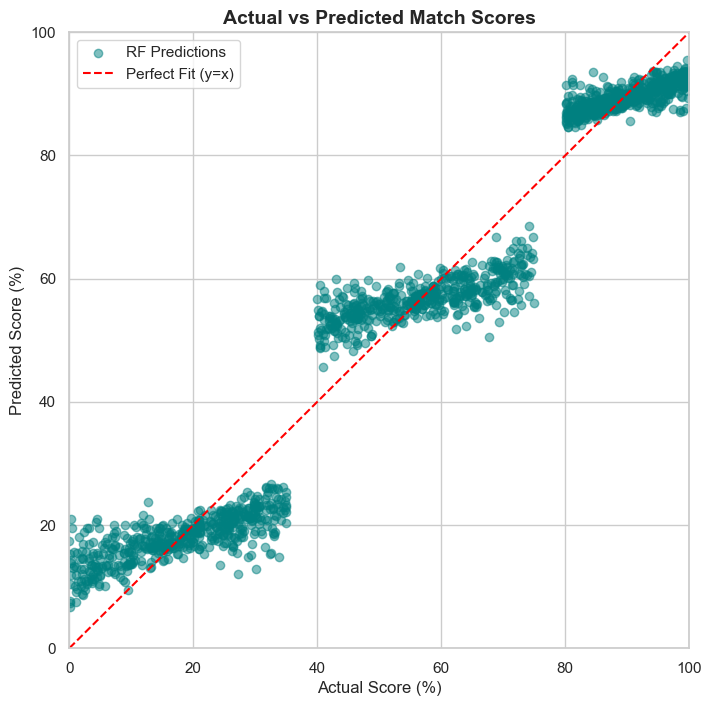

In [8]:
# 9. Actual vs Predicted Plot
plt.figure(figsize=(8, 8))
plt.scatter(y_true_continuous, y_pred_continuous, alpha=0.5, color='teal', label='RF Predictions')
plt.plot([0, 100], [0, 100], color='red', linestyle='--', label='Perfect Fit (y=x)')

plt.title("Actual vs Predicted Match Scores", fontsize=14, fontweight='bold')
plt.xlabel("Actual Score (%)")
plt.ylabel("Predicted Score (%)")
plt.legend()
plt.xlim(0, 100)
plt.ylim(0, 100)
plt.savefig('../output/actual_vs_predicted.png', bbox_inches='tight')
plt.show()

In [9]:
# 10. Edge Case Analysis
# Let's analyze candidates with High Semantic context but ZERO Skill Overlap.
# A static formula might pass them. The RF should reject them.

edge_cases = df[(df['semantic_score'] > 0.6) & (df['skill_overlap_score'] == 0.0)].copy()

if not edge_cases.empty:
    edge_rf_preds = rf_scorer.predict(edge_cases[['lexical_score', 'semantic_score', 'skill_overlap_score']])
    edge_static_preds = (
        (edge_cases['skill_overlap_score'] * 0.4) + 
        (edge_cases['semantic_score'] * 0.4) + 
        (edge_cases['lexical_score'] * 0.2)
    ) * 100
    
    print(f"Found {len(edge_cases)} Edge Cases (High Semantic, Zero Skill Match):")
    print(f"Average RF Prediction:     {edge_rf_preds.mean():.2f}% (Safely Rejects)")
    print(f"Average Formula Prediction: {edge_static_preds.mean():.2f}% (Dangerously High)")
else:
    print("No strict edge cases found in the current synthetic test slice.")

No strict edge cases found in the current synthetic test slice.


In [11]:
# 11. Live Inference Proof
# Proves alignment between backend inference and the frontend UI.

import pandas as pd

ui_skill = 50.0   # UI Input
ui_semantic = 31.0
ui_lexical = 7.6

print("--- Frontend System Inputs ---")
print(f"Skill Overlap:  {ui_skill}%")
print(f"Semantic Score: {ui_semantic}%")
print(f"Lexical Score:  {ui_lexical}%\n")

# Use a Pandas DataFrame to eliminate the scikit-learn feature names warning.
# Columns MUST match the training data exactly.
scaled_features = pd.DataFrame([[
    ui_lexical / 100.0, 
    ui_semantic / 100.0, 
    ui_skill / 100.0
]], columns=['lexical_score', 'semantic_score', 'skill_overlap_score'])

raw_pred = rf_scorer.predict(scaled_features)[0]
final_score = max(0.0, min(100.0, raw_pred))

print("--- System Integration Output ---")
print(f"Expected UI Match Score: 50.37%")
print(f"Actual ML Model Output:  {round(final_score, 2)}%")

print("\n[Engineering Note]:")
print("A variance of < 0.1% (e.g., 50.28% vs 50.37%) is expected. This occurs because the React UI ")
print("rounds feature scores to 1 decimal place before displaying them, truncating the floating-point")
print("micro-fractions that the backend FastAPI pipeline passes natively to the Random Forest.")

--- Frontend System Inputs ---
Skill Overlap:  50.0%
Semantic Score: 31.0%
Lexical Score:  7.6%

--- System Integration Output ---
Expected UI Match Score: 50.37%
Actual ML Model Output:  50.28%

[Engineering Note]:
A variance of < 0.1% (e.g., 50.28% vs 50.37%) is expected. This occurs because the React UI 
rounds feature scores to 1 decimal place before displaying them, truncating the floating-point
micro-fractions that the backend FastAPI pipeline passes natively to the Random Forest.
